In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf
import seaborn as sns

### 1. Generate Synthetic IoT Data


In [2]:
np.random.seed(0)
num_samples = 1000
temperature = np.random.uniform(20, 30, num_samples)  # Random temperature data
humidity = np.random.uniform(40, 60, num_samples)  # Random humidity data
target_variable = temperature * 0.5 + humidity * 0.3 + np.random.normal(0, 2, num_samples)  # Linear combination

# Create DataFrame
iot_data = pd.DataFrame({'Temperature': temperature, 'Humidity': humidity, 'Target': target_variable})

### 2. Explore IoT Data

This section performs initial data exploration to understand the structure, content, and basic statistics of the generated `iot_data` DataFrame.

In [3]:
print("First 5 rows of iot_data:")
display(iot_data.head())

First 5 rows of iot_data:


,Temperature,Humidity,Target
0,25.488135,51.857605,28.091390
1,27.151894,40.201274,28.371159
2,26.027634,49.516524,24.558086
3,25.448832,54.175408,29.284327
4,24.236548,40.879509,21.213179


In [4]:
print("\nInfo about iot_data:")
display(iot_data.info())


Info about iot_data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  1000 non-null   float64
 1   Humidity     1000 non-null   float64
 2   Target       1000 non-null   float64
dtypes: float64(3)
memory usage: 23.6 KB


None

In [5]:
print("\nDescriptive statistics for iot_data:")
display(iot_data.describe())


Descriptive statistics for iot_data:


,Temperature,Humidity,Target
count,1000.000000,1000.000000,1000.000000
mean,24.959215,50.227000,27.498208
std,2.907443,5.982156,2.957974
min,20.005460,40.007347,19.345463
25%,22.476135,45.104287,25.383524
50%,24.813226,50.389749,27.407830
75%,27.372603,55.561964,29.546000
max,29.998086,59.970532,35.827232


### 3. Visualize Data Correlations

This section visualizes the relationships between variables in the `iot_data` DataFrame, starting with a scatter plot between 'Temperature' and 'Target', followed by a correlation heatmap for all variables.

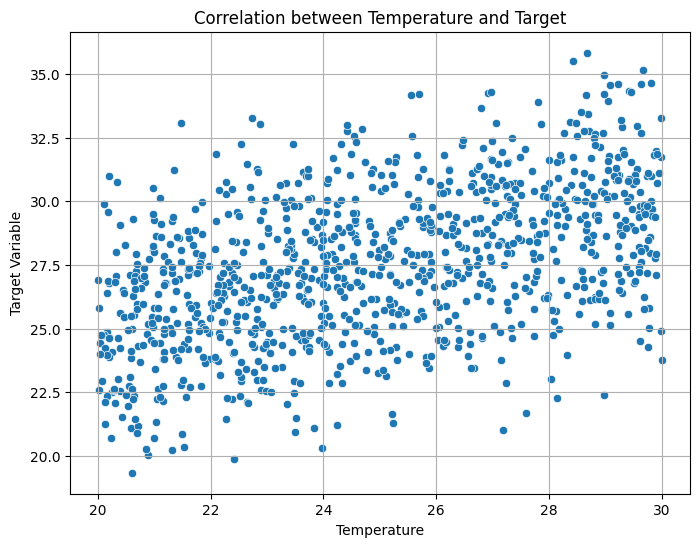

In [6]:
# Scatter plot for Temperature vs. Target
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Temperature', y='Target', data=iot_data)
plt.title('Correlation between Temperature and Target')
plt.xlabel('Temperature')
plt.ylabel('Target Variable')
plt.grid(True)
plt.show()

The scatter plot for 'Temperature' vs 'Target' has been successfully displayed. It visually reinforces the moderate positive correlation (0.48) we observed in the correlation matrix. You can see a general upward trend, indicating that as temperature increases, the target variable also tends to increase.

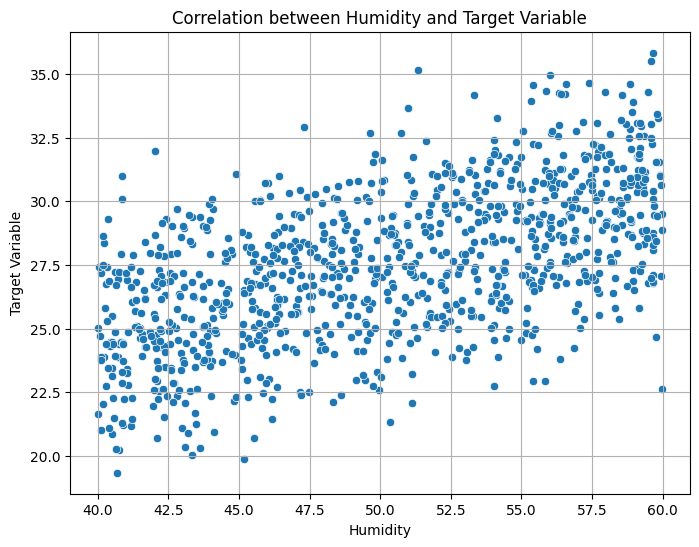

In [7]:
# Scatter plot for Humidity vs. Target
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Humidity', y='Target', data=iot_data)
plt.title('Correlation between Humidity and Target Variable')
plt.xlabel('Humidity')
plt.ylabel('Target Variable')
plt.grid(True)
plt.show()

The scatter plot for 'Humidity' vs 'Target' has been successfully displayed. Similar to 'Temperature', this plot visually confirms the moderate positive correlation (0.58) between 'Humidity' and the 'Target' variable that we observed in the correlation matrix. You can see a general upward trend, indicating that higher humidity levels tend to correspond with higher target variable values.



### Points to understand
  The primary difference lies in the strength of their correlation. As we saw in the correlation matrix:
* 'Temperature' vs 'Target' has a correlation coefficient of 0.48.
* 'Humidity' vs 'Target' has a correlation coefficient of 0.58.

This means that the relationship between **'Humidity' and 'Target'** is slightly stronger than the relationship between **'Temperature' and 'Target'**.
Visually, you might observe that the points in the *'Humidity' vs 'Target' plot are slightly more clustered or tightly grouped around an imaginary trend line compared to the 'Temperature' vs 'Target' plot, although both show a clear positive trend.*


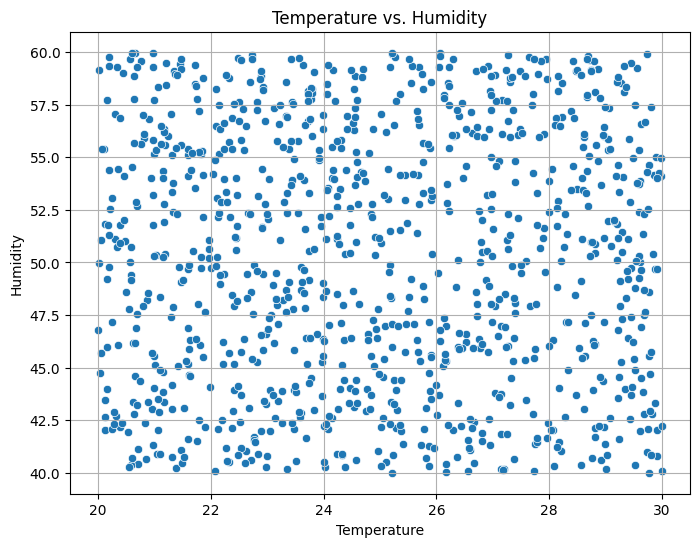

In [8]:
# Scatter plot for Temperature vs. Humidity
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Temperature', y='Humidity', data=iot_data)
plt.title('Temperature vs. Humidity')
plt.xlabel('Temperature')
plt.ylabel('Humidity')
plt.grid(True)
plt.show()

The scatter plot of 'Temperature' vs. 'Humidity' shows a random distribution of points, with no clear pattern or trend. This visually confirms the very low correlation (0.01) we observed earlier in the correlation matrix, indicating that these two variables are largely independent in our synthetic dataset.

In [9]:
correlation_matrix = iot_data.corr()
print("Correlation Matrix of IoT Data:")
display(correlation_matrix)

Correlation Matrix of IoT Data:


,Temperature,Humidity,Target
Temperature,1.000000,0.006017,0.480315
Humidity,0.006017,1.000000,0.583155
Target,0.480315,0.583155,1.000000


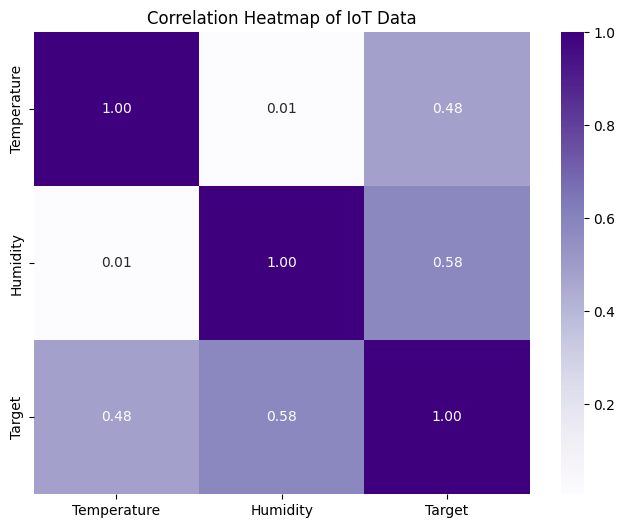

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='Purples', fmt='.2f')
plt.title('Correlation Heatmap of IoT Data')
plt.show()

From the correlation matrix:

*   **Temperature** shows a moderate positive correlation with the **Target** variable (0.48).
*   **Humidity** shows a moderate positive correlation with the **Target** variable (0.58).
*   The correlation between **Temperature** and **Humidity** is very low (0.01), indicating they are largely independent of each other in this synthetic dataset.

### 4. Prepare Data for Linear Regression

Here, the data is split into features (X) and target (y), and then further divided into training and testing sets to prepare for model training and evaluation.

In [11]:
# Split data into features and target variable
X = iot_data[['Temperature', 'Humidity']]
y = iot_data['Target']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

### 5. Train Linear Regression Model

A Linear Regression model is initialized and fitted to the training data to learn the relationship between 'Temperature', 'Humidity', and the 'Target' variable.

In [12]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
linear_reg_model = LinearRegression()

# Fit the model to the training data. This step learns the coefficients and intercept.
linear_reg_model.fit(X_train, y_train)

# Print a confirmation message that the model has been trained.
print("Linear Regression model trained.")

# Print the learned coefficients for each feature (Temperature, Humidity).
# These coefficients represent the change in the Target variable for a one-unit change in the respective feature.
print(f"Model Coefficients: {linear_reg_model.coef_}")

# Print the learned intercept of the model.
# The intercept is the predicted Target value when all feature values are zero.
print(f"Model Intercept: {linear_reg_model.intercept_}")

Linear Regression model trained.
Model Coefficients: [0.49497799 0.28730565]
Model Intercept: 0.7531653146656296


### 6. Evaluate Model Performance

The trained model's performance is evaluated using Root Mean Squared Error (RMSE) on both the training and test sets, and actual versus predicted values are visualized.

In [13]:
# Predict on training data
train_predictions = linear_reg_model.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, train_predictions))
print(f"Root Mean Squared Error (RMSE) on training data: {rmse_train}")

Root Mean Squared Error (RMSE) on training data: 1.95157487928933


In [14]:
# Predict on test data
predictions = linear_reg_model.predict(X_test)

# Calculate RMSE on test data
rmse_test = np.sqrt(mean_squared_error(y_test, predictions))
print(f"Root Mean Squared Error (RMSE) on test data: {rmse_test}")

Root Mean Squared Error (RMSE) on test data: 1.9191030050246154


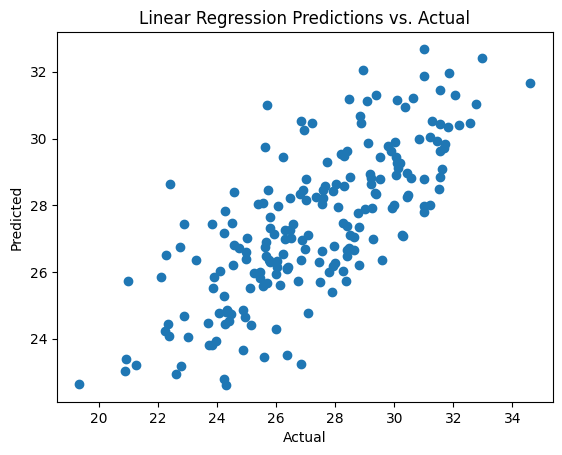

In [15]:
# Visualize predictions vs. actual
plt.scatter(y_test, predictions)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Linear Regression Predictions vs. Actual')
plt.show()

### Interpretation of Model Coefficients and Intercept

The trained Linear Regression model has provided the following parameters:

*   **Model Coefficients:**
    *   `Temperature`: `0.49497799`
    *   `Humidity`: `0.28730565`

*   **Model Intercept:** `0.7531653146656296`

These values define our linear regression equation as:

`Target = (0.495 * Temperature) + (0.287 * Humidity) + 0.753`

Let's break down what each of these means:

1.  **Intercept (0.753):**
    *   The intercept represents the predicted value of the `Target` variable when all independent variables (`Temperature` and `Humidity`) are zero. In many real-world scenarios, features being zero might not be physically meaningful, but mathematically, it's the baseline prediction.

2.  **Coefficient for Temperature (0.495):**
    *   This coefficient indicates that for every one-unit increase in `Temperature`, the `Target` variable is predicted to increase by approximately `0.495` units, assuming `Humidity` remains constant.

3.  **Coefficient for Humidity (0.287):**
    *   This coefficient indicates that for every one-unit increase in `Humidity`, the `Target` variable is predicted to increase by approximately `0.287` units, assuming `Temperature` remains constant.


**In summary, both Temperature and Humidity have a positive linear relationship with the Target variable. A change in Temperature has a slightly stronger impact on the Target variable compared to an equivalent change in Humidity.**


In [16]:
r_squared_train = linear_reg_model.score(X_train, y_train)
print(f"R-squared on training data: {r_squared_train}")

R-squared on training data: 0.5696770361764609


In [17]:
r_squared_test = linear_reg_model.score(X_test, y_test)
print(f"R-squared on test data: {r_squared_test}")

R-squared on test data: 0.5517600977879945


### Interpretation of R-squared Values

*   **R-squared on training data:** This value represents the proportion of the variance in the dependent variable (Target) that is predictable from the independent variables (Temperature and Humidity) in the training set.
*   **R-squared on test data:** Similar to the training R-squared, this value indicates how well the model explains the variance in the Target variable for unseen data (the test set).

An R-squared closer to 1 indicates that a larger proportion of the variance is explained by the model, suggesting a better fit. Conversely, an R-squared closer to 0 indicates that the model explains very little of the variance.